In [ ]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocesado y modelado
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#from sklearn.metrics import plot_confusion_matrix
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Configuración matplotlib
# ==============================================================================
plt.rcParams['image.cmap'] = "bwr"
#plt.rcParams['figure.dpi'] = "100"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [ ]:
datos = pd.read_excel(io ='BD_SARA_v3.xlsx')
datos.head(3)

,Año_Ingreso,Asignatura_critica,Dpto_curso_pregrado,Dpto_curso_ingles,Dpto_curso_salud,Dpto_curso_sociales_huma,Dpto_curso_nat_y_tec,Carrera_curso_agro,Carrera_curso_enf,Carrera_curso_icind,...,Atenciones_salud_mental,Maternidad_paternidad,N_asignaturas_inscritas_semestre,Progresión_académica_SCT,SCT_curso,Asig_crítica_frecuente,Pertenencia_PO,Nivel_educ_madre,Nivel_educ_padre,Estado_Asignatura
0,2019,0,0,0,0,1,0,0,0,0,...,0,1,6,97.826087,5,0,0,2,1,1
1,2019,0,0,1,0,0,0,0,0,0,...,0,1,6,97.826087,3,0,0,2,1,1
2,2019,0,0,0,0,1,0,0,0,0,...,0,1,6,97.826087,5,0,0,2,1,1


In [ ]:
import pandas as pd

# Cargar tu DataFrame o adaptar según tu estructura de datos
# df = pd.read_csv('tu_archivo.csv')

# Obtener el listado de nombres de las variables
nombres_variables = datos.columns.tolist()

# Mostrar el listado de nombres de las variables
print("Nombres de las variables:")
print(nombres_variables)


Nombres de las variables:
['Año_Ingreso', 'Asignatura_critica', 'Dpto_curso_pregrado', 'Dpto_curso_ingles', 'Dpto_curso_salud', 'Dpto_curso_sociales_huma', 'Dpto_curso_nat_y_tec', 'Carrera_curso_agro', 'Carrera_curso_enf', 'Carrera_curso_icind', 'Carrera_Curso_icinf', 'Carrera_curso_ifor', 'Carrera_curso_obs', 'Carrera_curso_psi', 'Carrera_curso_tsoc', 'Carrera_curso_multiple', 'Nota_parcial_1', 'Nota_parcial_2', 'Nota_parcial_3', 'Nota_parcial_4', 'Nota_final_est', 'N_estudiantes_reprueban', 'N_estudiantes_encurso', 'Nota_final_curso', 'Porcen_aproba_curso', 'Semestre_academico', 'Año_academico', 'Puntaje_lm', 'Puntaje_rnk', 'Sexo', 'Depto_estudiante_salud', 'Depto_estudiante_soc_hum', 'Depto_estudiante_nat_tec', 'Carrera_est_agro', 'Carrera_est_enf', 'Carrera_est_icind', 'Carrera_est_icinf', 'Carrera_est_ifor', 'Carrera_est_obs', 'Carrera_est_psi', 'Carrera_est_tsocial', 'Tipo_ingreso_Regular', 'Tipo_ingreso_Repostulación', 'Tipo_ingreso_BEA', 'Tipo_ingreso_PACE', 'Tipo_ingreso_Espec

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar tu DataFrame con todas las variables
# Puedes adaptar esta parte según el formato y la ubicación de tu base de datos
# df = pd.read_csv('tu_archivo.csv')

# Definir la variable independiente y las variables dependientes
variable_independiente = 'Estado_Asignatura'
variables_dependientes = [col for col in datos.columns if col != variable_independiente]

# Dividir el DataFrame en variables independientes y dependientes
X = datos.drop(variable_independiente, axis=1)
y = datos[variables_dependientes]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construir y ajustar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')







Mean Squared Error: 8.258742737274104e-27
R-squared: 0.9848484848484849


# **MODELO (1)**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Cargar tu DataFrame con todas las variables
# Puedes adaptar esta parte según el formato y la ubicación de tu base de datos
# df = pd.read_csv('tu_archivo.csv')

# Definir la variable independiente y las variables dependientes
variable_independiente = 'Estado_Asignatura'
variables_dependientes = [col for col in datos.columns if col != variable_independiente]

# Dividir el DataFrame en variables independientes y dependientes
X = datos[variables_dependientes]
X = sm.add_constant(X)  # Añadir una constante para el término independiente

y = datos[variable_independiente]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construir y ajustar el modelo de regresión lineal con Statsmodels
model = sm.OLS(y_train, X_train).fit()

# Mostrar el resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Estado_Asignatura   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     854.8
Date:                Wed, 13 Dec 2023   Prob (F-statistic):               0.00
Time:                        13:58:27   Log-Likelihood:                 5431.8
No. Observations:               16961   AIC:                        -1.074e+04
Df Residuals:                   16900   BIC:                        -1.027e+04
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

# **MODELO (2)**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

datos = pd.read_excel(io ='BD_SARA_v4.xlsx')
datos.head(3)

# Cargar tu DataFrame con todas las variables
# Puedes adaptar esta parte según el formato y la ubicación de tu base de datos
# df = pd.read_csv('tu_archivo.csv')

# Definir la variable independiente y las variables dependientes
variable_independiente = 'Estado_Asignatura'
variables_dependientes = [col for col in datos.columns if col != variable_independiente]

# Dividir el DataFrame en variables independientes y dependientes
X = datos[variables_dependientes]
X = sm.add_constant(X)  # Añadir una constante para el término independiente

y = datos[variable_independiente]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construir y ajustar el modelo de regresión lineal con Statsmodels
model = sm.OLS(y_train, X_train).fit()

# Mostrar el resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Estado_Asignatura   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.471
Method:                 Least Squares   F-statistic:                     286.3
Date:                Wed, 29 Nov 2023   Prob (F-statistic):               0.00
Time:                        21:15:32   Log-Likelihood:                -965.73
No. Observations:               16961   AIC:                             2039.
Df Residuals:                   16907   BIC:                             2457.
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

# **MODELO (3)**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

datos = pd.read_excel(io ='BD_SARA_v5.xlsx')
datos.head(3)

# Cargar tu DataFrame con todas las variables
# Puedes adaptar esta parte según el formato y la ubicación de tu base de datos
# df = pd.read_csv('tu_archivo.csv')

# Definir la variable independiente y las variables dependientes
variable_independiente = 'Estado_Asignatura'
variables_dependientes = [col for col in datos.columns if col != variable_independiente]

# Dividir el DataFrame en variables independientes y dependientes
X = datos[variables_dependientes]
X = sm.add_constant(X)  # Añadir una constante para el término independiente

y = datos[variable_independiente]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construir y ajustar el modelo de regresión lineal con Statsmodels
model = sm.OLS(y_train, X_train).fit()

# Mostrar el resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Estado_Asignatura   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     479.7
Date:                Thu, 30 Nov 2023   Prob (F-statistic):               0.00
Time:                        11:13:13   Log-Likelihood:                -1052.2
No. Observations:               16961   AIC:                             2168.
Df Residuals:                   16929   BIC:                             2416.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

# **MODELO (4)**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

datos = pd.read_excel(io ='BD_SARA_v6.xlsx')
datos.head(3)

# Cargar tu DataFrame con todas las variables
# Puedes adaptar esta parte según el formato y la ubicación de tu base de datos
# df = pd.read_csv('tu_archivo.csv')

# Definir la variable independiente y las variables dependientes
variable_independiente = 'Estado_Asignatura'
variables_dependientes = [col for col in datos.columns if col != variable_independiente]

# Dividir el DataFrame en variables independientes y dependientes
X = datos[variables_dependientes]
X = sm.add_constant(X)  # Añadir una constante para el término independiente

y = datos[variable_independiente]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construir y ajustar el modelo de regresión lineal con Statsmodels
model = sm.OLS(y_train, X_train).fit()

# Mostrar el resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Estado_Asignatura   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     550.5
Date:                Thu, 30 Nov 2023   Prob (F-statistic):               0.00
Time:                        11:22:13   Log-Likelihood:                -1054.7
No. Observations:               16961   AIC:                             2165.
Df Residuals:                   16933   BIC:                             2382.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [ ]:
print("Número de observaciones por clase")
print(datos['Estado_Asignatura'].value_counts())
print("")

print("Porcentaje de observaciones por clase")
print(100 * datos['Estado_Asignatura'].value_counts(normalize=True))

Número de observaciones por clase
1    18118
0     3084
Name: Estado_Asignatura, dtype: int64

Porcentaje de observaciones por clase
1    85.454202
0    14.545798
Name: Estado_Asignatura, dtype: float64


In [ ]:
# Predicciones con intervalo de confianza
# ==============================================================================
predicciones = model.predict(exog = X_train)

# Clasificación predicha
# ==============================================================================
clasificacion = np.where(predicciones<0.5, 0, 1)
clasificacion

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
# Accuracy de test del modelo
# ==============================================================================
X_test = sm.add_constant(X_test, prepend=True)
predicciones = model.predict(exog = X_test)
clasificacion = np.where(predicciones<0.5, 0, 1)
accuracy = accuracy_score(
            y_true    = y_test,
            y_pred    = clasificacion,
            normalize = True
           )
print("")
print(f"El accuracy de test es: {100*accuracy}%")


El accuracy de test es: 91.18132515916058%


In [ ]:
# Matriz de confusión de las predicciones de test
# ==============================================================================
confusion_matrix = pd.crosstab(
    y_test.ravel(),
    clasificacion,
    rownames=['Real'],
    colnames=['Predicción']
)
confusion_matrix

Predicción,0,1
Real,,
0,308,304
1,70,3559


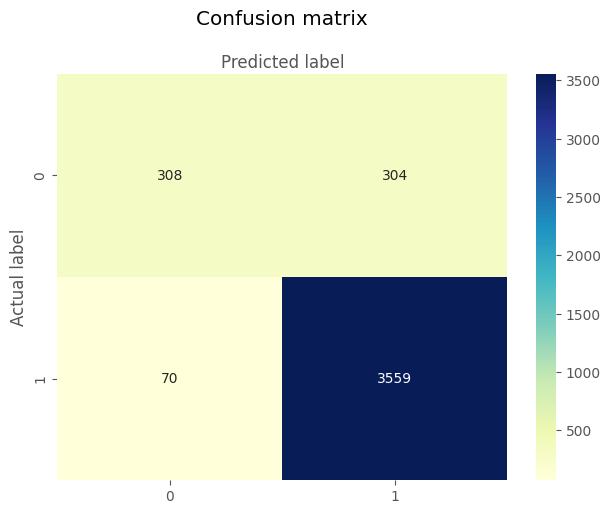

In [ ]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(confusion_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label');

# **MODELO (4)**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

datos = pd.read_excel(io ='BD_SARA_v7.xlsx')
datos.head(3)

# Cargar tu DataFrame con todas las variables
# Puedes adaptar esta parte según el formato y la ubicación de tu base de datos
# df = pd.read_csv('tu_archivo.csv')

# Definir la variable independiente y las variables dependientes
variable_independiente = 'Estado_Asignatura'
variables_dependientes = [col for col in datos.columns if col != variable_independiente]

# Dividir el DataFrame en variables independientes y dependientes
X = datos[variables_dependientes]
X = sm.add_constant(X)  # Añadir una constante para el término independiente

y = datos[variable_independiente]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construir y ajustar el modelo de regresión lineal con Statsmodels
model = sm.OLS(y_train, X_train).fit()

# Mostrar el resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Estado_Asignatura   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     588.9
Date:                Wed, 13 Dec 2023   Prob (F-statistic):               0.00
Time:                        14:02:24   Log-Likelihood:                -1252.1
No. Observations:               16961   AIC:                             2554.
Df Residuals:                   16936   BIC:                             2748.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

# **MODELO (5_VF)**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

datos = pd.read_excel(io ='BD_SARA_vf.xlsx')
datos.head(3)

# Cargar tu DataFrame con todas las variables
# Puedes adaptar esta parte según el formato y la ubicación de tu base de datos
# df = pd.read_csv('tu_archivo.csv')

# Definir la variable independiente y las variables dependientes
variable_independiente = 'Estado_Asignatura'
variables_dependientes = [col for col in datos.columns if col != variable_independiente]

# Dividir el DataFrame en variables independientes y dependientes
X = datos[variables_dependientes]
X = sm.add_constant(X)  # Añadir una constante para el término independiente

y = datos[variable_independiente]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construir y ajustar el modelo de regresión lineal con Statsmodels
model = sm.OLS(y_train, X_train).fit()

# Mostrar el resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Estado_Asignatura   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     614.5
Date:                Wed, 13 Dec 2023   Prob (F-statistic):               0.00
Time:                        14:05:22   Log-Likelihood:                -1252.6
No. Observations:               16961   AIC:                             2553.
Df Residuals:                   16937   BIC:                             2739.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [ ]:
print("Número de observaciones por clase")
print(datos['Estado_Asignatura'].value_counts())
print("")

print("Porcentaje de observaciones por clase")
print(100 * datos['Estado_Asignatura'].value_counts(normalize=True))

Número de observaciones por clase
1    18118
0     3084
Name: Estado_Asignatura, dtype: int64

Porcentaje de observaciones por clase
1    85.454202
0    14.545798
Name: Estado_Asignatura, dtype: float64


In [ ]:
# Predicciones con intervalo de confianza
# ==============================================================================
predicciones = model.predict(exog = X_train)

# Clasificación predicha
# ==============================================================================
clasificacion = np.where(predicciones<0.5, 0, 1)
clasificacion

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
# Accuracy de test del modelo
# ==============================================================================
X_test = sm.add_constant(X_test, prepend=True)
predicciones = model.predict(exog = X_test)
clasificacion = np.where(predicciones<0.5, 0, 1)
accuracy = accuracy_score(
            y_true    = y_test,
            y_pred    = clasificacion,
            normalize = True
           )
print("")
print(f"El accuracy de test es: {100*accuracy}%")


El accuracy de test es: 90.82763499174723%


In [ ]:
# Matriz de confusión de las predicciones de test
# ==============================================================================
confusion_matrix = pd.crosstab(
    y_test.ravel(),
    clasificacion,
    rownames=['Real'],
    colnames=['Predicción']
)
confusion_matrix

Predicción,0,1
Real,,
0,301,311
1,78,3551


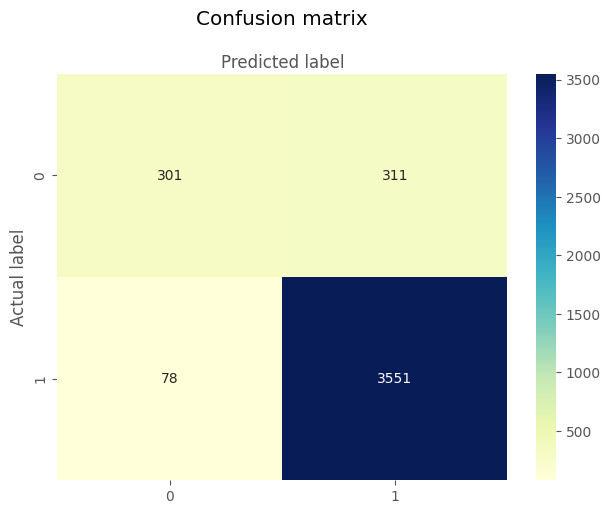

In [ ]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(confusion_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label');